In [1]:
from uncertainties import ufloat
from uncertainties.umath import * 
from uncertainties import unumpy

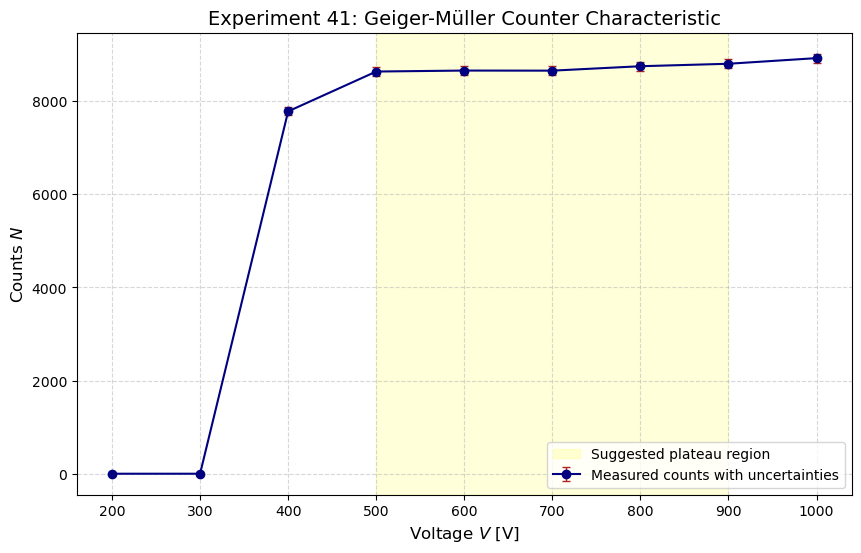

Voltage (V) | Counts (N) | Time (s) | Error sqrt(N)
-------------------------------------------------------
200          | 0           | 60.0     | 0.00
300          | 0           | 60.0     | 0.00
400          | 7781        | 60.0     | 88.21
500          | 8636        | 60.0     | 92.93
600          | 8657        | 60.0     | 93.04
700          | 8655        | 60.0     | 93.03
800          | 8750        | 60.0     | 93.54
900          | 8803        | 60.0     | 93.82
1000         | 8924        | 60.0     | 94.47


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Spannungen V in Volt
V = np.array([200, 300, 400, 500, 600, 700, 800, 900, 1000])

# Gemessene Impulse N 
N = np.array([
    0, 0,  7781, 8636, 8657, 8655, 8750, 8803, 8924
])


t = np.array([
    60,  
    60,   
    60,   
    60,    
    60,    
    60,   
    60,    
    60,    
    60,    
])


fehler = np.sqrt(N)

# Plot erstellen
plt.figure(figsize=(10, 6))

plt.errorbar(V, N, yerr=fehler, fmt='o-', color='navy', 
             ecolor='firebrick', elinewidth=1, capsize=3, label='Measured counts with uncertainties')

plt.axvspan(500, 900, color='yellow', alpha=0.15, label='Suggested plateau region')


plt.xlabel('Voltage $V$ [V]', fontsize=12)
plt.ylabel('Counts $N$', fontsize=12)
plt.title('Experiment 41: Geiger-Müller Counter Characteristic', fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.savefig('Geiger-Mueller-counter.png', dpi=600)
plt.show()


print("Voltage (V) | Counts (N) | Time (s) | Error sqrt(N)")
print("-" * 55)
for i in range(len(V)):
    print(f"{V[i]:<12} | {N[i]:<11} | {t[i]:<8.1f} | {fehler[i]:.2f}")

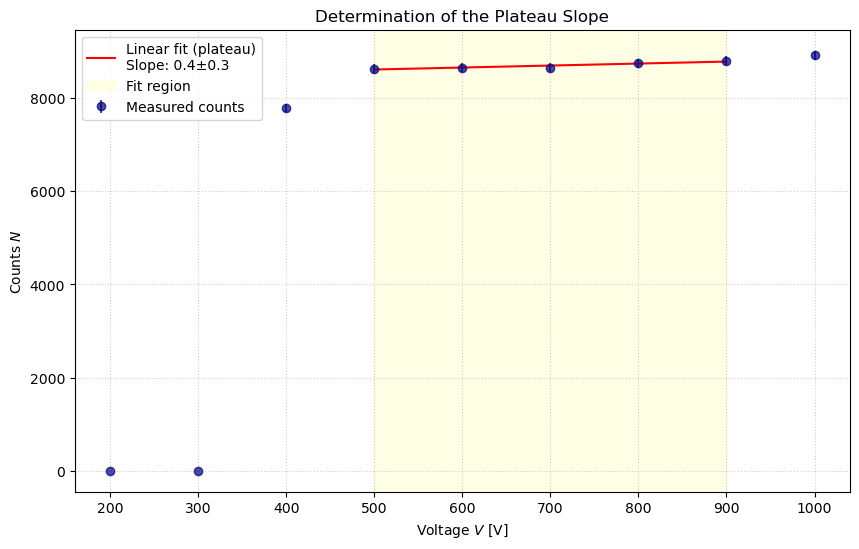

Results of the plateau fit:
Slope (a) = dN/dV: 0.42624 +/- 0.29523 [1/V]
Intercept (b): 8401.77 +/- 210.55
Relative slope per 100 V: 0.49+/-0.33 %
V_ideal = 700 V


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat


mask = (V >= 500) & (V <= 900)
V_plateau = V[mask]
N_plateau = N[mask]
N_err_plateau = fehler[mask]

# Fit-Funktion definieren 
def linear(x, a, b):
    return a * x + b

# Den Fit durchführen 
params, cov = curve_fit(linear, V_plateau, N_plateau, sigma=N_err_plateau, absolute_sigma=True)
a, b = params


a_err = np.sqrt(cov[0, 0])
b_err = np.sqrt(cov[1, 1])

a_u = ufloat(a, a_err)
b_u = ufloat(b, b_err)

# Plotten
plt.figure(figsize=(10, 6))


plt.errorbar(V, N, yerr=fehler, fmt='o', color='navy', label='Measured counts', alpha=0.7)

# Die Fit-Gerade im Plateaubereich
V_fit_range = np.linspace(500, 900, 100)
plt.plot(
    V_fit_range,
    linear(V_fit_range, a, b),
    'r-',
    label=f'Linear fit (plateau)\nSlope: {a_u:.1uP}'
)


plt.axvspan(500, 900, color='yellow', alpha=0.1, label='Fit region')

plt.xlabel('Voltage $V$ [V]')
plt.ylabel('Counts $N$')
plt.title('Determination of the Plateau Slope')
plt.legend()
plt.grid(True, ls=':', alpha=0.6)
plt.savefig('Geiger-Mueller-counter_fit.png', dpi=600)
plt.show()

# Ergebnisse ausgeben 
print("Results of the plateau fit:")
print(f"Slope (a) = dN/dV: {a:.5f} +/- {a_err:.5f} [1/V]")
print(f"Intercept (b): {b:.2f} +/- {b_err:.2f}")
N_mitte = linear(np.mean(V_plateau), a_u, b_u)
steigung_prozent = (a_u * 100 / N_mitte) * 100
print(f"Relative slope per 100 V: {steigung_prozent:.2f} %")

print("V_ideal = 700 V")

In [4]:
 import numpy as np

# =========================
# MESSWERTE EINTRAGEN
# =========================

N_roh = 8743        
N_BG_roh = 35     
t = 60          
N=ufloat(N_roh,sqrt(N_roh))
N_BG = ufloat(N_BG_roh,sqrt(N_BG_roh))
r = ufloat(8.5,0.05)          
d = ufloat(101,0.05)         

# =========================
# BERECHNUNGEN
# =========================
N_eff = N - N_BG
theta = atan(r / d)
epsilon = sin(theta / 2)**2
A = N_eff / (epsilon * t)
# =========================
# KORREKTUR (Stahlfolie)
# =========================
verlust = 0.325   # 32.5% Verlust
A_korr = A / (1 - verlust)
# =========================
# OUTPUT
# =========================
print("N_eff =", N_eff)
print("theta =", theta, "rad")
print("epsilon =", epsilon)
print("Aktivität (roh) =", A, "Bq")
print(f"Aktivität (korrigiert) = {A_korr:.1uL} Bq")

N_eff = (8.71+/-0.09)e+03
theta = 0.0840+/-0.0005 rad
epsilon = 0.001761+/-0.000021
Aktivität (roh) = (8.24+/-0.13)e+04 Bq
Aktivität (korrigiert) = \left(1.22 \pm 0.02\right) \times 10^{5} Bq


In [5]:
import numpy as np

# -----------------------------
# Mean lifetime calculation
# -----------------------------

T_half_Sr = 28.8 
T_half_Y = 64    
tau_Sr = T_half_Sr / np.log(2)
tau_Y = T_half_Y / np.log(2)
print("Mean lifetime Sr (years):", tau_Sr)
print("Mean lifetime Y (hours):", tau_Y)

# -----------------------------
# Time until activity reaches 10 kBq
# -----------------------------

A0 = A_korr 
A_target = 10000  
t_decay = tau_Sr * log(A0 / A_target)
print("Time until 10 kBq (years):", t_decay)

# -----------------------------
# Activity in the past
# -----------------------------

t_1950 = 2026 - 1950 
A_1950 = A0 * np.exp(t_1950 / tau_Sr)
print("Activity in the past (Bq):", A_1950)

# -----------------------------
# Radiation dose calculation
# -----------------------------

S = 5.5e-3  
k = 2.8e-8  
dose_rate = A0 * k
time_needed = S / dose_rate
print("Dose rate (Sv/s):", dose_rate)
print("Time to reach 5.5 mSv (s):", time_needed)



Mean lifetime Sr (years): 41.54961717760215
Mean lifetime Y (hours): 92.33248261689366
Time until 10 kBq (years): 104.0+/-0.7
Activity in the past (Bq): (7.60+/-0.12)e+05
Dose rate (Sv/s): 0.00342+/-0.00005
Time to reach 5.5 mSv (s): 1.609+/-0.026


x [mm]    rho*x [mg/cm^2]    E(x) [MeV]
 0.00           0.000            nan
 0.24          64.560         0.2122
 0.50         134.500         0.3481
 0.75         201.750         0.4661
 1.00         269.000         0.5783
 1.25         336.250         0.6873
 1.50         403.500         0.7942
 1.75         470.750         0.8997
 2.00         538.000         1.0042
 2.25         605.250         1.1078
 2.50         672.500         1.2109
 2.75         739.750         1.3134
 3.00         807.000         1.4156
 3.50         941.500         1.6191
 4.00        1076.000         1.8216

FEHLERANALYSE METHODE 1
Ablesewert x_mm:      2.75 +/- 0.10 mm
Resultierendes E_max: 1.313 +/- 0.041 MeV
----------------------------------------
Detail: E(2.85mm) = 1.354 MeV
Detail: E(2.65mm) = 1.272 MeV


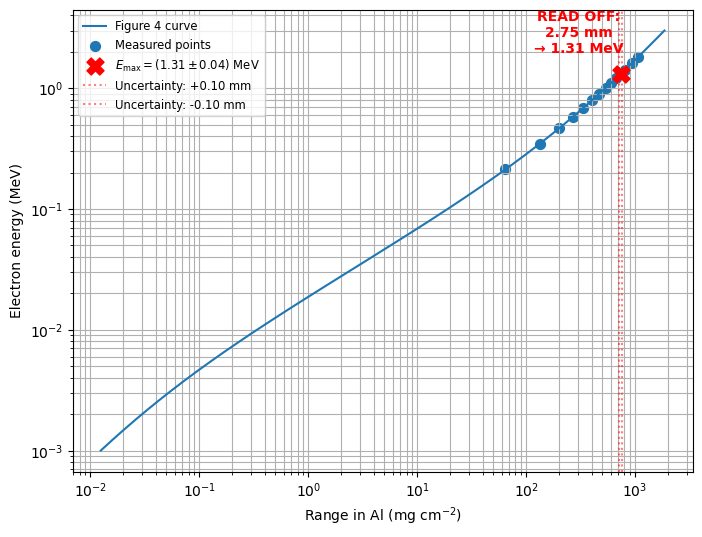

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- dein Fig.-4-Code ----------
def Range(A, B, C, E):
    return A * E * (1 - B / (1 + C * E))

a = 1.479 * 10**(-3)
B = 0.9852
C = 3.73
A = 1 / a

# ---------- deine Dicken x aus dem Protokollblatt [mm] ----------
x_mm = np.array([
    0.00, 0.24, 0.50, 0.75,1.00, 1.25, 1.50, 1.75,
    2.00, 2.25, 2.50, 2.75, 3.00, 3.50, 4.00
], dtype=float)
rho_Al = 2.69 
x_cm = x_mm / 10.0
rho_x_g = rho_Al * x_cm           
rho_x_mg = rho_x_g * 1000.0        

# ---------- numerische Umkehrfunktion: aus Reichweite -> Energie ----------
E_grid = np.linspace(0.001, 3.0, 300000)     
R_grid = Range(A, B, C, E_grid)               

def energy_from_range(R_target):
    idx = np.argmin(np.abs(R_grid - R_target))
    return E_grid[idx]

# ---------- E(x) berechnen ----------
E_x = np.array([np.nan if r == 0 else energy_from_range(r) for r in rho_x_mg])

# ---------- Werte ausgeben ----------
print("x [mm]    rho*x [mg/cm^2]    E(x) [MeV]")
for x, r, e in zip(x_mm, rho_x_mg, E_x):
    print(f"{x:5.2f}      {r:10.3f}        {e:7.4f}")



# ==========================================================
# ERGÄNZUNG: Markierung von E_max (Methode 1: Grafisch)
# ==========================================================
x_knick_mm = 2.75  
R_max_mg = (x_knick_mm / 10.0) * rho_Al * 1000.0
E_max_meth1 = energy_from_range(R_max_mg)
# ==========================================================
# UNSICHERHEIT METHODE 1 (Ablesegenauigkeit)
# ==========================================================

s_x_mm = 0.1  

R_upper_mg = ((x_knick_mm + s_x_mm) / 10.0) * rho_Al * 1000.0
R_lower_mg = ((x_knick_mm - s_x_mm) / 10.0) * rho_Al * 1000.0


E_upper = energy_from_range(R_upper_mg)
E_lower = energy_from_range(R_lower_mg)


s_E_meth1 = max(abs(E_upper - E_max_meth1), abs(E_max_meth1 - E_lower))

# 4. Ausgabe der Ergebnisse
print("\n" + "="*40)
print("FEHLERANALYSE METHODE 1")
print("="*40)
print(f"Ablesewert x_mm:      {x_knick_mm:.2f} +/- {s_x_mm:.2f} mm")
print(f"Resultierendes E_max: {E_max_meth1:.3f} +/- {s_E_meth1:.3f} MeV")
print("-" * 40)
print(f"Detail: E({x_knick_mm + s_x_mm:.2f}mm) = {E_upper:.3f} MeV")
print(f"Detail: E({x_knick_mm - s_x_mm:.2f}mm) = {E_lower:.3f} MeV")
print("="*40)

# ---------- Plot of Fig. 4 + highlighted measurement points ----------
plt.figure(figsize=(8,6))

plt.loglog(R_grid, E_grid, label="Figure 4 curve")
plt.scatter(rho_x_mg[1:], E_x[1:], s=50, label="Measured points")

plt.scatter(R_max_mg, E_max_meth1, color='red', s=150, marker='X', zorder=10,
            label=rf"$E_{{\max}} = ({E_max_meth1:.2f} \pm {s_E_meth1:.2f})\ \mathrm{{MeV}}$")

plt.annotate(f"READ OFF:\n{x_knick_mm} mm\n→ {E_max_meth1:.2f} MeV",
             (R_max_mg, E_max_meth1),
             textcoords="offset points",
             xytext=(-30, 15),
             color='red',
             fontweight='bold',
             ha='center')


plt.axvline(x=R_upper_mg, color='red', linestyle=':', alpha=0.5,
            label=f"Uncertainty: +{s_x_mm:.2f} mm")
plt.axvline(x=R_lower_mg, color='red', linestyle=':', alpha=0.5,
            label=f"Uncertainty: -{s_x_mm:.2f} mm")

plt.grid(True, which="both", ls="-")
plt.ylabel("Electron energy (MeV)")
plt.xlabel(r"Range in Al (mg cm$^{-2}$)")
plt.legend(loc='best', fontsize='small')


plt.savefig('range_uncertainty_plot.png', dpi=300, bbox_inches='tight')

plt.show()


--- Tabelle ---


,x [mm],rho*x [g/cm^2],t [s],N,N_eff,A_meas [Bq],E(x) [MeV],E_max - E(x) [MeV]
0,0.00,0.00000,60.0,(8.74+/-0.09)e+03,(8.72+/-0.09)e+03,145.3+/-1.6,NaN,NaN
1,0.24,0.06456,60.0,(2.75+/-0.05)e+03,(2.73+/-0.05)e+03,45.4+/-0.9,0.212170,1.957830
2,0.50,0.13450,60.0,(1.87+/-0.04)e+03,(1.85+/-0.04)e+03,30.8+/-0.7,0.348145,1.821855
3,0.75,0.20175,60.0,(1.37+/-0.04)e+03,(1.34+/-0.04)e+03,22.4+/-0.6,0.466066,1.703934
4,1.00,0.26900,60.0,928+/-30,902+/-30,15.0+/-0.5,0.578319,1.591681
5,1.25,0.33625,60.0,475+/-22,449+/-22,7.5+/-0.4,0.687323,1.482677
6,1.50,0.40350,60.0,416+/-20,390+/-20,6.50+/-0.34,0.794248,1.375752
7,1.75,0.47075,60.0,293+/-17,267+/-17,4.45+/-0.29,0.899733,1.270267
8,2.00,0.53800,60.0,185+/-14,159+/-14,2.65+/-0.23,1.004169,1.165831
9,2.25,0.60525,60.0,103+/-10,77+/-10,1.28+/-0.17,1.107825,1.062175


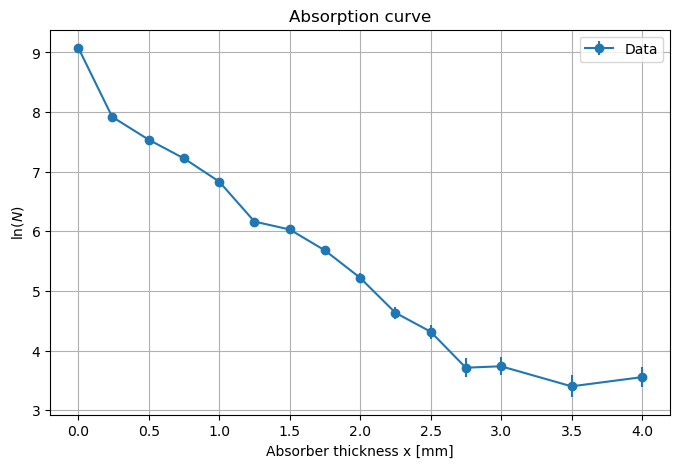

a = -1.62642 ± 0.08845 1/mm
b = 8.36660 ± 0.08555

--- Fit-Ergebnisse ---
Steigung a = -1.62642 1/mm
mu = 1.62642+/-0.08845 1/mm
mu = 16.26417+/-0.88455 1/cm

--- Ergebnis E_max ---
E_max (aus mu) = 2.060+/-0.078 MeV

--- Fit-Ergebnisse ---
Steigung a = -1.62642 1/mm
mu = 1.62642+/-0.08845 1/mm
mu = 16.26417+/-0.88455 1/cm


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

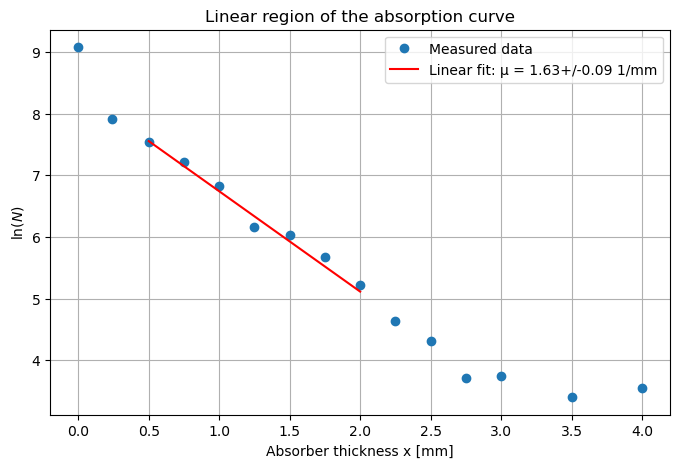

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================
# 1) Gegebene Dicken (Protokollblatt)
# ==================================
x_mm = np.array([
    0.00, 0.24, 0.50, 0.75,1.00, 1.25, 1.50, 1.75,
    2.00, 2.25, 2.50, 2.75, 3.00, 3.50, 4.00
], dtype=float)

# ==================================
# 2) Konstanten
# ==================================
rho_Al = 2.69       
t = 60.0            
x_cm = x_mm / 10.0
rho_x = rho_Al * x_cm
# ==================================
# 3) Messwerte (HIER DEINE WERTE EINTRAGEN!)
# ==================================
N_roh = np.array([
    8743, 
    2751,  
    1873, 
    1369,  
    928,  
    475,  
    416,   
    293,   
    185,   
    103,   
    75,   
    41, 
    42,   
    30,   
    35    
])
N_sigma=np.sqrt(N_roh) 
N=unumpy.uarray(N_roh,N_sigma)
N_BG = 26

# ==================================
# 4) Berechnungen
# ==================================

N_eff = N - N_BG
A_meas = N_eff / t

# ==================================
# 5) E(x) (aus Fig. 4 ablesen!)
# ==================================

E_max_guess = 2.17  

E_max_minus_E = E_max_guess - E_x

# ==================================
# 6) Tabelle anzeigen
# ==================================
df = pd.DataFrame({
    "x [mm]": x_mm,
    "rho*x [g/cm^2]": rho_x,
    "t [s]": np.full_like(x_mm, t),
    "N": N,
    "N_eff": N_eff,
    "A_meas [Bq]": A_meas,
    "E(x) [MeV]": E_x,
    "E_max - E(x) [MeV]": E_max_minus_E
})

print("\n--- Tabelle ---")
display(df)

# ==================================
# 7) Absorptionskurve (ln(N_eff) vs x)
# ==================================

mask = (unumpy.nominal_values(N) > 0) 
y_vals = unumpy.log(N[mask])
y_nominal = unumpy.nominal_values(y_vals)
y_err = unumpy.std_devs(y_vals)

plt.figure(figsize=(8,5))
plt.errorbar(x_mm[mask], y_nominal, yerr=y_err, fmt='o-', label='Data')

plt.xlabel('Absorber thickness x [mm]')
plt.ylabel(r'$\ln(N)$')
plt.title('Absorption curve')
plt.grid(True)
plt.legend()
plt.savefig('absorption_curve.png', dpi=300, bbox_inches='tight')

plt.show()

# ==================================
# 8) Linearer Fit (nur erster Bereich!)
# ==================================

fit_mask = (x_mm >= 0.5) & (x_mm <= 2.0) & (unumpy.nominal_values(N_eff) > 0)

x_fit = x_mm[fit_mask]

y_fit_unc = unumpy.log(N_eff[fit_mask])

x_fit_nom = x_fit 
y_fit_nom = unumpy.nominal_values(y_fit_unc)
y_fit_err = unumpy.std_devs(y_fit_unc)
p, cov = np.polyfit(x_fit_nom, y_fit_nom, 1, w=1/y_fit_err, cov=True)
a, b = p
a_err, b_err = np.sqrt(np.diag(cov))

print(f"a = {a:.5f} ± {a_err:.5f} 1/mm")
print(f"b = {b:.5f} ± {b_err:.5f}")

a_u = ufloat(a, a_err)

mu_mm_u = -a_u
mu_cm_u = mu_mm_u * 10



print("\n--- Fit-Ergebnisse ---")
print(f"Steigung a = {a:.5f} 1/mm")
print(f"mu = {mu_mm_u:.5f} 1/mm")
print(f"mu = {mu_cm_u:.5f} 1/cm")

# Plot mit Fit
x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
y_line = a * x_line + b

plt.figure(figsize=(8,5))

# ==================================
# 9) E_max aus mu berechnen
# ==================================
E_max_from_mu = ((17 * rho_Al) / mu_cm_u) ** (1 / 1.43)

print("\n--- Ergebnis E_max ---")
print(f"E_max (aus mu) = {E_max_from_mu:.3f} MeV")


print("\n--- Fit-Ergebnisse ---")
print(f"Steigung a = {a:.5f} 1/mm")
print(f"mu = {mu_mm_u:.5f} 1/mm")
print(f"mu = {mu_cm_u:.5f} 1/cm")


x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
y_line = a * x_line + b

plt.figure(figsize=(8,5))


y_all_nom = unumpy.nominal_values(unumpy.log(N[mask]))

plt.figure(figsize=(8,5))

plt.plot(x_mm[mask], y_all_nom, 'o', label='Measured data')
plt.plot(x_line, y_line, '-', color='red',
         label=f'Linear fit: μ = {mu_mm_u:.2f} 1/mm')

plt.xlabel('Absorber thickness x [mm]')
plt.ylabel(r'$\ln(N)$')
plt.title('Linear region of the absorption curve')
plt.grid(True)
plt.legend()

plt.savefig('linear_region_absorption_curve.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:

# ==================================
# 10) Korrektur für die Stahlfolie
# ==================================
Delta_E_Folie_M1 = 0.105
E_max_source_M1 = E_max_meth1 + Delta_E_Folie_M1

print("\n--- Korrektur Stahlfolie von E_max Methode 1 ---")
print(f"E_max (nach Folie)   = {E_max_meth1:.3f} +/- {s_E_meth1:.3f} MeV")
print(f"Energieverlust Folie = {Delta_E_Folie_M1:.3f} MeV")
print(f"E_max Source (total) = {E_max_source_M1:.3f} +/- {s_E_meth1:.3f}  MeV")


Delta_E_Folie_M2 = 0.116  

E_max_source = E_max_from_mu + Delta_E_Folie_M2

print("\n--- Korrektur Stahlfolie von E_max Methode 2 ---")
print(f"E_max (nach Folie)   = {E_max_from_mu:.3f} MeV")
print(f"Energieverlust Folie = {Delta_E_Folie_M2:.3f} MeV")
print(f"E_max Source (total) = {E_max_source:.3f} MeV")


--- Korrektur Stahlfolie von E_max Methode 1 ---
E_max (nach Folie)   = 1.313 +/- 0.041 MeV
Energieverlust Folie = 0.105 MeV
E_max Source (total) = 1.418 +/- 0.041  MeV

--- Korrektur Stahlfolie von E_max Methode 2 ---
E_max (nach Folie)   = 2.060+/-0.078 MeV
Energieverlust Folie = 0.116 MeV
E_max Source (total) = 2.176+/-0.078 MeV


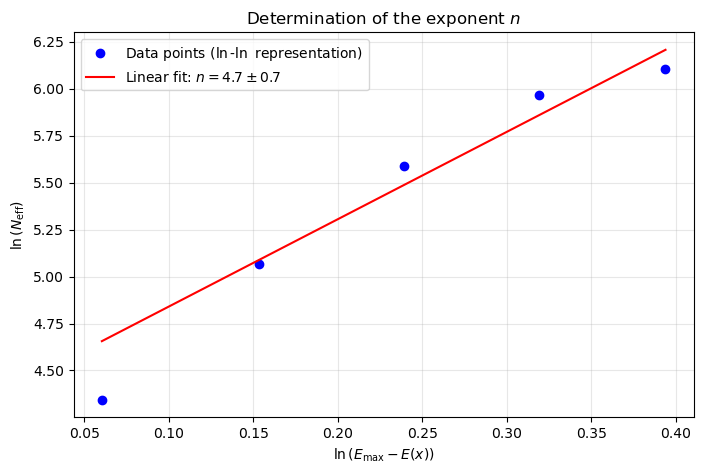

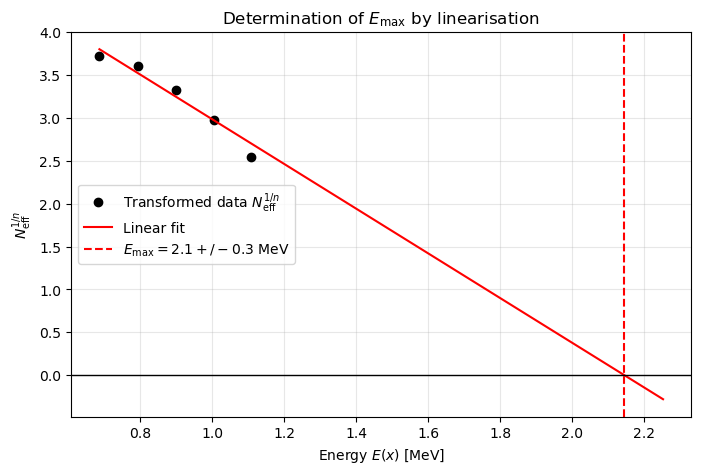

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import unumpy

# ==========================================================
# 1) DATENSELEKTION (Filterung aus deinem DataFrame 'df')
# ==========================================================
mask_task5 = (df["x [mm]"] >= 1.25) & (df["x [mm]"] <= 2.25)

E_x_f = df["E(x) [MeV]"][mask_task5].values
N_eff_f = df["N_eff"][mask_task5].values
E_diff_f = df["E_max - E(x) [MeV]"][mask_task5].values

# ==========================================================
# 2) SCHRITT 1: BESTIMMUNG VON n (Log-Log Darstellung)
# ==========================================================
X1 = np.log(E_diff_f) 

Y1_unc = unumpy.log(N_eff_f)
Y1_sigma = unumpy.std_devs(Y1_unc)
weights = 1 / Y1_sigma  


p1, cov1 = np.polyfit(X1, unumpy.nominal_values(Y1_unc), 1, w=weights, cov=True)
n_slope = p1[0]
intercept1 = p1[1]
sigma_n = np.sqrt(cov1[0, 0])

# --- PLOT 1: Determination of n ---
plt.figure(figsize=(8, 5))

# Data points
plt.plot(
    X1,
    unumpy.nominal_values(Y1_unc),
    'o',
    color='blue',
    label=r'Data points ($\ln$-$\ln$ representation)'
)

# Fit line
plt.plot(
    X1,
    n_slope * X1 + intercept1,
    '-',
    color='red',
    label=fr'Linear fit: $n = {n_slope:.1f} \pm {sigma_n:.1f}$'
)


plt.xlabel(r'$\ln\left(E_{\max} - E(x)\right)$')
plt.ylabel(r'$\ln\left(N_{\mathrm{eff}}\right)$')


plt.title('Determination of the exponent $n$')


plt.grid(True, alpha=0.3)
plt.legend()


plt.savefig('plot_n_fit.png', dpi=300, bbox_inches='tight')

plt.show()

# ==========================================================
# 3) SCHRITT 2: VERBESSERTES E_max (Linearisierung)
# ==========================================================
n = n_slope

Y2_unc = N_eff_f**(1.0 / n)
X2 = E_x_f


Y2_nom = unumpy.nominal_values(Y2_unc)
Y2_sigma = unumpy.std_devs(Y2_unc)


weights = 1 / Y2_sigma  

p2, cov2 = np.polyfit(X2, Y2_nom, 1, w=weights, cov=True)
a, b = p2
a2 = ufloat(a, np.sqrt(cov2[0, 0]))
b2 = ufloat(b, np.sqrt(cov2[1, 1]))

E_max_improved = -b2 / a2



# --- PLOT 2: Determination of E_max ---
plt.figure(figsize=(8, 5))


plt.plot(
    X2,
    Y2_nom,
    'o',
    color='black',
    label=r'Transformed data $N_{\mathrm{eff}}^{1/n}$'
)


x_fit = np.linspace(
    X2.min(),
    unumpy.nominal_values(E_max_improved) * 1.05,
    100
)

plt.plot(
    x_fit,
    unumpy.nominal_values(a2) * x_fit + unumpy.nominal_values(b2),
    '-',
    color='red',
    label='Linear fit'
)


plt.axvline(
    unumpy.nominal_values(E_max_improved),
    color='red',
    linestyle='--',
    label=fr'$E_{{\max}} = {E_max_improved:.1f}\ \mathrm{{MeV}}$'
)


plt.axhline(0, color='black', linewidth=1)


plt.xlabel(r'Energy $E(x)$ [MeV]')
plt.ylabel(r'$N_{\mathrm{eff}}^{1/n}$')


plt.title(r'Determination of $E_{\max}$ by linearisation')


plt.grid(True, alpha=0.3)
plt.legend()


plt.savefig('plot_Emax_linearisation.png', dpi=300, bbox_inches='tight')

plt.show()
